In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# --- Load Clay's metrics ---
import glob

clay_metrics_file = sorted(glob.glob('models_study/clay_no_deficit_v2/clay_no_deficit_v2_metrics_*.json'))[-1]
print(f'Loading: {clay_metrics_file}')

with open(clay_metrics_file) as f:
    clay_metrics = json.load(f)

# First entry is pre-training eval, skip it
clay_metrics = clay_metrics[1:]

clay_train_loss = [m['training_loss'] for m in clay_metrics]
clay_test_loss  = [m['test_loss'] for m in clay_metrics]
clay_test_acc   = [m['test_accuracy'] * 100 for m in clay_metrics]  # convert 0-1 to 0-100

In [ ]:
# --- Load your metrics (auto-detect latest exp_id) ---
import os

exp_ids = sorted(os.listdir('debug_output/data'), key=lambda x: os.path.getmtime(f'debug_output/data/{x}'))
exp_id = exp_ids[-1]
print(f'Loading exp_id: {exp_id}')

base = f'debug_output/data/{exp_id}'

your_train_loss = pd.read_csv(f'{base}/train_losses.csv')['train_loss'].tolist()
your_test_loss  = pd.read_csv(f'{base}/test_losses.csv')['test_loss'].tolist()
your_test_acc   = pd.read_csv(f'{base}/test_accs.csv')['test_acc'].tolist()

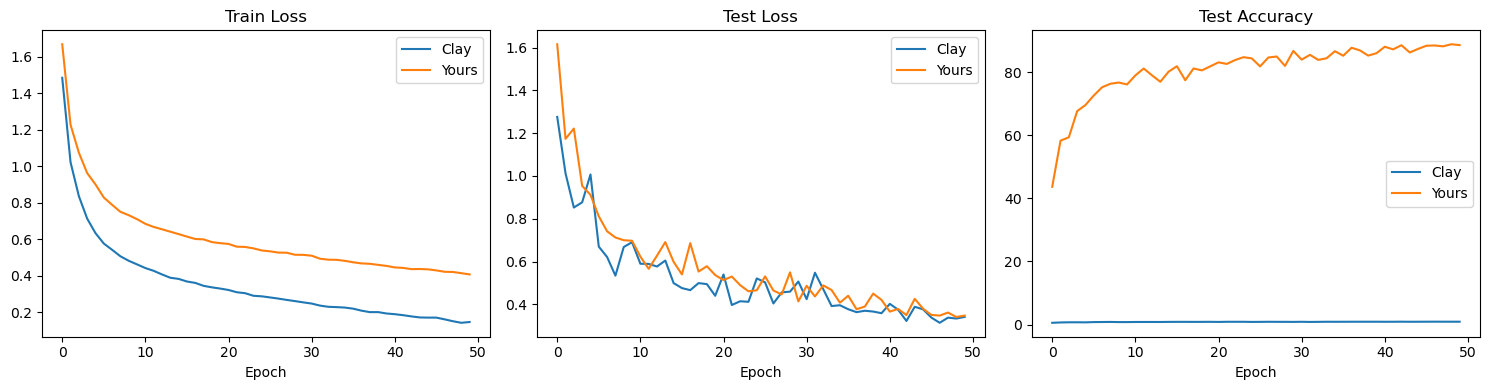

In [4]:
epochs = range(min(len(clay_train_loss), len(your_train_loss)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, clay_train_loss[:len(epochs)], label='Clay')
axes[0].plot(epochs, your_train_loss[:len(epochs)], label='Yours')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, clay_test_loss[:len(epochs)], label='Clay')
axes[1].plot(epochs, your_test_loss[:len(epochs)], label='Yours')
axes[1].set_title('Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs, clay_test_acc[:len(epochs)], label='Clay')
axes[2].plot(epochs, your_test_acc[:len(epochs)], label='Yours')
axes[2].set_title('Test Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()